# Amazon Review Rating Predictor — NLP & Regression

**Goal:** Predict the numeric star rating (1–5) of an Amazon Software review purely from its raw text, using TF-IDF, structural features, and sentiment analysis, compared across Linear Regression, Ridge, and XGBoost.

**Dataset:** Amazon Reviews 2023 (McAuley Lab), Software category, sampled to 200,000 reviews.


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style("whitegrid")
pd.set_option('display.max_colwidth', 200)


## 2. Load Dataset

Download the raw JSONL file for the Software category directly from Hugging Face before running this cell:

```bash
curl -L -O "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Software.jsonl"
```


In [2]:
df = pd.read_json("Software.jsonl", lines=True)
print(df.shape)
df.head()


(4880181, 10)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1,malware,mcaffee IS malware,[],B07BFS3G7P,B0BQSK9QCF,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,2019-07-03 19:37:12.076,0,False
1,5,Lots of Fun,"I love playing tapped out because it is fun to watch the town grow by earning money and buying buildings. I love helping my neighbors, too.",[],B00CTQ6SIG,B00CTQ6SIG,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-02-16 20:58:56.000,0,True
2,5,Light Up The Dark,"I love this flashlight app! It really illuminates the dark, very cool! Get this app, you will love it, really!",[],B0066WJLU6,B0066WJLU6,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2013-03-04 12:14:27.000,0,True
3,4,Fun game,One of my favorite games,[],B00KCYMAWK,B00KCYMAWK,AH6CATODIVPVUOJEWHRSRCSKAOHA,2019-06-20 20:10:28.662,0,True
4,4,I am not that good at it but my kids are,Cute game. I am not that good at it but my kids are. We love Nik Wallenda!,[],B00P1RK566,B00P1RK566,AEINY4XOINMMJCK5GZ3M6MMHBN6A,2014-12-11 00:19:56.000,0,True


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4880181 entries, 0 to 4880180
Data columns (total 10 columns):
 #   Column             Dtype         
---  ------             -----         
 0   rating             int64         
 1   title              str           
 2   text               str           
 3   images             object        
 4   asin               str           
 5   parent_asin        str           
 6   user_id            str           
 7   timestamp          datetime64[ms]
 8   helpful_vote       int64         
 9   verified_purchase  bool          
dtypes: bool(1), datetime64[ms](1), int64(2), object(1), str(5)
memory usage: 1.3+ GB


In [4]:
df['rating'].value_counts().sort_index()


rating
1     695854
2     239253
3     419356
4     857082
5    2668636
Name: count, dtype: int64

In [5]:
df.describe()


,rating,timestamp,helpful_vote
count,4.880181e+06,4880181,4.880181e+06
mean,3.935087e+00,2016-08-11 20:56:15.320000,4.921711e+00
min,1.000000e+00,1999-03-15 04:02:39,-1.000000e+00
25%,3.000000e+00,2014-09-03 01:27:03,0.000000e+00
50%,5.000000e+00,2016-03-19 18:49:49,0.000000e+00
75%,5.000000e+00,2018-08-15 19:51:14.231000,2.000000e+00
max,5.000000e+00,2023-09-11 02:13:11.515000,1.026700e+04
std,1.451875e+00,NaN,3.516860e+01


In [6]:
df.isnull().sum()


rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

## 3. Data Cleaning

Checks performed:
- Blank/whitespace-only review text
- Exact duplicate reviews (same text + rating)
- Confirmed duplicates are genuine repeated reviews (not coincidental short phrases) by inspecting samples


In [7]:
# Check for blank text
print("Blank text rows:", (df['text'].str.strip() == '').sum())

# Check for duplicates
print("Duplicate text+rating rows (all copies):", df.duplicated(subset=['text', 'rating'], keep=False).sum())


Blank text rows: 324
Duplicate text+rating rows (all copies): 877347


In [8]:
# Drop blank-text rows
df = df[df['text'].str.strip() != '']

# Drop exact duplicate reviews, keep first occurrence
df = df.drop_duplicates(subset=['text', 'rating'], keep='first')

print("Shape after cleaning:", df.shape)


Shape after cleaning: (4120992, 10)


## 4. Sampling

The cleaned dataset is still several million rows. Sample down to a representative, manageable working set while preserving the real (skewed) rating distribution.


In [9]:
df_sample = df.sample(n=200000, random_state=42)
df = df_sample.reset_index(drop=True)

print(df.shape)
print(df['rating'].value_counts(normalize=True).sort_index())


(200000, 10)
rating
1    0.14980
2    0.05318
3    0.09115
4    0.18219
5    0.52368
Name: proportion, dtype: float64


## 5. Exploratory Data Analysis

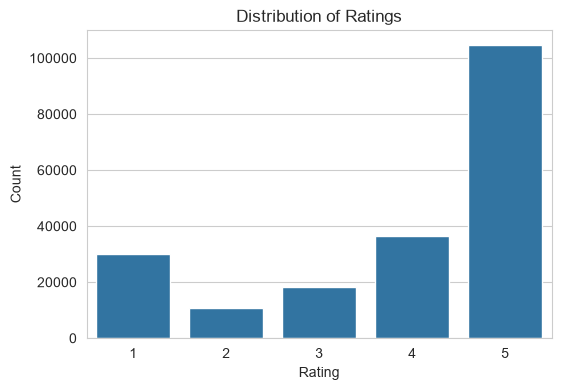

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


In [11]:
df['word_count'] = df['text'].str.split().str.len()
df['word_count'].describe()


count    200000.000000
mean         30.394255
std          50.150254
min           1.000000
25%           9.000000
50%          20.000000
75%          32.000000
max        3390.000000
Name: word_count, dtype: float64

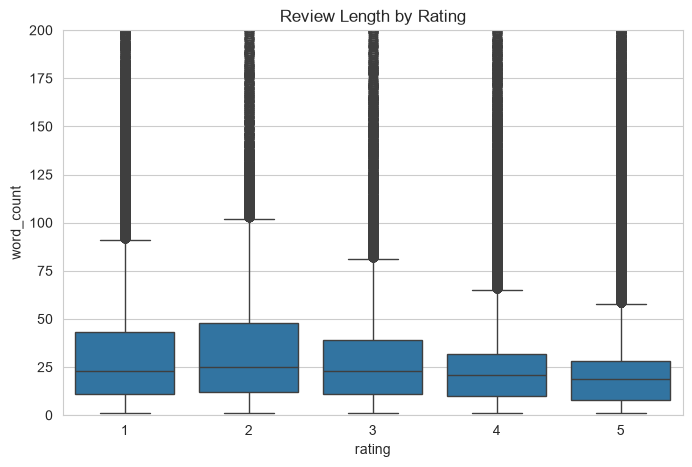

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='rating', y='word_count', data=df)
plt.title('Review Length by Rating')
plt.ylim(0, 200)
plt.show()


**Finding:** Median review length decreases roughly monotonically from 1-star/2-star reviews down to 5-star reviews — reviewers leaving lower or mixed ratings tend to write more, likely explaining their complaint in detail, while 5-star reviewers often write short, generic praise.


In [13]:
# Inspect the longest reviews to confirm they are genuine (not scraping artifacts)
df.sort_values('word_count', ascending=False)[['rating', 'text', 'word_count']].head(5)


,rating,text,word_count
80013,4,"FULL DISCLOSURE: I am a Beta Tester for FxHome. My license for Hitfilm 4 Pro comes directly from FxHome, so I am not an “Amazon Verified Purchaser.” FxHome has not asked for, nor compensated me fo...",3390
81147,5,"Overview<br /><br />The Encyclopedia Britannica has long been much more than a venerable print reference work. More than a decade ago it pioneered a freemium website (some content free, other cont...",2458
131110,3,"Originally, I gave this game 1 star in a fit of anger and disappointment. However, I've had some time to cool off. Now, I'm going to try and be as objective in this review as I possibly can so tha...",2402
53280,4,"Start Menu:<br /><br />Obviously the start menu switching its focus to apps and the fact that Windows 8 boots directly to this screen rather than the desktop is what makes Windows 8, Windows 8, ra...",2352
80052,4,"Bento was released by the makers of FileMaker Pro with a very specific purpose. Interestingly, Bento was the name given to a layer in Apple's visionary OpenDoc architecture launched with System 7....",2254


## 6. Text Cleaning — HTML / URL Removal

Raw review text contains leftover HTML artifacts (`<br />`, `&#34;`) and occasional bare URLs. Build a cleaned version (`text_clean`) while keeping the original `text` column intact for punctuation-dependent structural features.


In [14]:
import re

def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)      # remove <br /> tags
    text = re.sub(r'&#\d+;', ' ', text)          # remove HTML entities like &#34;
    text = re.sub(r'http\S+|www\S+', ' ', text)  # remove URLs
    text = re.sub(r'\s+', ' ', text).strip()     # collapse multiple spaces
    return text

df['text_clean'] = df['text'].apply(clean_text)

# Check for rows that became empty after cleaning (e.g. reviews that were ONLY a URL)
print("Empty after cleaning:", (df['text_clean'].str.strip() == '').sum())
df[df['text_clean'].str.strip() == ''][['text', 'text_clean']]


Empty after cleaning: 7


,text,text_clean
20286,https://www.amazon.com/gp/product/B00T1GXL0K/ref=cm_cr_ryp_prd_ttl_sol_49,
63707,www.google.com,
89489,https://images-na.ssl-images-amazon.com/images/I/51QK1IuXaWL._SS300_.png,
102605,www.amazon.com/dp/B01M1MP90U/ref=cm_cr_ryp_prd_ttl_sol_6,
149830,https://www.amazon.com/dp/B005ZXWMUS/ref=cm_cr_ryp_prd_ttl_sol_2,
152411,https://www.tumblr.com/search/queenhope,
196346,http://www.amazon.com/Brennasoft-LLC-Drudge-on-Droid/dp/B008KC1SOM?ie=UTF8&redirect=true&ref_=cm_cr_ryp_prd_ttl_sol_1,


In [15]:
# Drop rows that are just bare URLs / no real content
df = df[df['text_clean'].str.strip() != '']
print(df.shape)


(199993, 12)


## 7. Structural & Sentiment Feature Engineering

- Sentence count & average sentence length (computed on raw `text`, since punctuation must stay intact)
- Exclamation / question mark counts
- VADER sentiment compound score (computed on `text_clean`)


In [16]:
def sentence_count(text):
    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if s.strip() != '']
    return len(sentences)

df['sentence_count'] = df['text'].apply(sentence_count)
df['avg_sentence_length'] = df['word_count'] / df['sentence_count'].replace(0, 1)
df['exclamation_count'] = df['text'].str.count('!')
df['question_count'] = df['text'].str.count(r'\?')


In [17]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
df['sentiment_compound'] = df['text_clean'].apply(lambda t: analyzer.polarity_scores(t)['compound'])

df[['rating', 'text_clean', 'sentiment_compound']].head(10)


,rating,text_clean,sentiment_compound
0,5,Great entertainment! Love it!,0.9133
1,4,A fun way to spend free time.,0.7650
2,1,This app does nothing but let you hear the sound of the mandolin's 4 courses of strings. No way to really play it that I could figure out.,0.1875
3,4,The game is ok. If you just want a simple game of bingo this is the game to play. No frills or annoying chats.,0.4133
4,4,"This product works well for me. Easy install,runs fast on scans, I'm not a computer wiz, but I have no virus!",-0.1511
5,5,N I central game,0.0000
6,5,"Candy Crush Saga is a great game with a very big imagination. It's just crazy, the level are sometimes challenging but fun. Highly addictive and like most mobile you can buy things to enhance your...",0.9216
7,4,I bought this product over Photoshop Elements because of price. It was about $20 instead of about $100 for Elements. I only need a product to generally edit and cleanup scans of older color slides...,0.7184
8,5,Great stand alone product if one does not want to pay for a provider.,0.4895
9,5,"For those of you concerned with the permissions you needn't worry. When you download this app it doesn't come with any of the permissions listed, in fact none at all. Also, in regards to being a f...",0.9568


In [18]:
corr_cols = ['rating', 'word_count', 'sentence_count', 'avg_sentence_length',
             'exclamation_count', 'question_count', 'sentiment_compound']
corr = df[corr_cols].corr()
corr


,rating,word_count,sentence_count,avg_sentence_length,exclamation_count,question_count,sentiment_compound
rating,1.000000,-0.119729,-0.110046,-0.073954,0.014401,-0.098562,0.553380
word_count,-0.119729,1.000000,0.901346,0.311323,0.027086,0.209734,0.047773
sentence_count,-0.110046,0.901346,1.000000,0.045897,0.044194,0.245993,0.066878
avg_sentence_length,-0.073954,0.311323,0.045897,1.000000,-0.007172,0.009779,0.015844
exclamation_count,0.014401,0.027086,0.044194,-0.007172,1.000000,0.024189,0.023315
question_count,-0.098562,0.209734,0.245993,0.009779,0.024189,1.000000,-0.053840
sentiment_compound,0.553380,0.047773,0.066878,0.015844,0.023315,-0.053840,1.000000


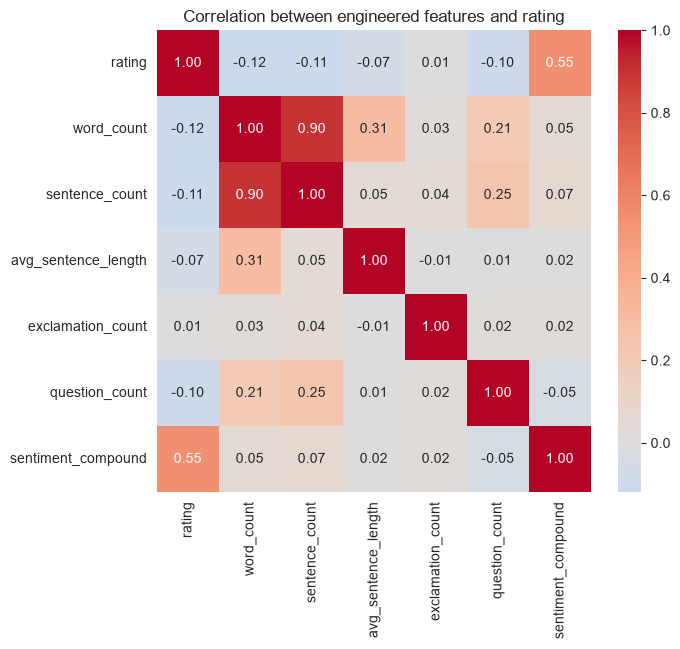

In [19]:
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between engineered features and rating")
plt.show()


**Finding:** `sentiment_compound` correlates most strongly with `rating` (~0.55) of all engineered features — confirming VADER sentiment carries real, usable signal. Structural features (word/sentence count) show weaker but consistent negative correlation with rating, echoing the length-by-rating pattern seen earlier.


## 8. Text Normalization for TF-IDF

Build a third text version (`text_tfidf`): lowercased, non-letters stripped, stopwords removed, lemmatized. Negation words (`not`, `no`, `nor`) are deliberately kept in, since removing them flips sentiment meaning (e.g. "not good" → "good").


In [20]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english')) - {'not', 'no', 'nor'}
lemmatizer = WordNetLemmatizer()

def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['text_tfidf'] = df['text_clean'].apply(normalize_text)
df[['text_clean', 'text_tfidf']].head(10)


,text_clean,text_tfidf
0,Great entertainment! Love it!,great entertainment love
1,A fun way to spend free time.,fun way spend free time
2,This app does nothing but let you hear the sound of the mandolin's 4 courses of strings. No way to really play it that I could figure out.,app nothing let hear sound mandolin course string no way really play could figure
3,The game is ok. If you just want a simple game of bingo this is the game to play. No frills or annoying chats.,game ok want simple game bingo game play no frill annoying chat
4,"This product works well for me. Easy install,runs fast on scans, I'm not a computer wiz, but I have no virus!",product work well easy install run fast scan not computer wiz no virus
5,N I central game,n central game
6,"Candy Crush Saga is a great game with a very big imagination. It's just crazy, the level are sometimes challenging but fun. Highly addictive and like most mobile you can buy things to enhance your...",candy crush saga great game big imagination crazy level sometimes challenging fun highly addictive like mobile buy thing enhance experience thus far could happen recommend anyone everyone
7,I bought this product over Photoshop Elements because of price. It was about $20 instead of about $100 for Elements. I only need a product to generally edit and cleanup scans of older color slides...,bought product photoshop element price instead element need product generally edit cleanup scan older color slide color negative black white family negative exceeded expectation term feature ease ...
8,Great stand alone product if one does not want to pay for a provider.,great stand alone product one not want pay provider
9,"For those of you concerned with the permissions you needn't worry. When you download this app it doesn't come with any of the permissions listed, in fact none at all. Also, in regards to being a f...",concerned permission worry download app come permission listed fact none also regard free app play store listen people check version play come level must pay play faotd come rest assured two thing...


## 9. TF-IDF Vectorization

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
X_tfidf = tfidf.fit_transform(df['text_tfidf'])

print(X_tfidf.shape)
print(tfidf.get_feature_names_out()[:30])


(199993, 5000)
['abc' 'ability' 'able' 'able access' 'able download' 'able find'
 'able get' 'able play' 'able see' 'able use' 'able watch' 'absolute'
 'absolutely' 'absolutely love' 'absolutely no' 'accept' 'acceptable'
 'accepted' 'access' 'accessible' 'accidentally' 'accomplish' 'according'
 'account' 'accountant' 'accounting' 'accuracy' 'accurate' 'accurately'
 'achieve']


In [22]:
from scipy.sparse import hstack, csr_matrix

structural_features = df[['word_count', 'sentence_count', 'avg_sentence_length',
                           'exclamation_count', 'question_count', 'sentiment_compound']].values

X_combined = hstack([X_tfidf, csr_matrix(structural_features)]).tocsr()
print(X_combined.shape)


(199993, 5006)


## 10. Train / Test Split

In [23]:
from sklearn.model_selection import train_test_split

y = df['rating'].astype(float)

indices = np.arange(len(df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

X_train, X_test = X_combined[train_idx], X_combined[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(X_train.shape, X_test.shape)


(159994, 5006) (39999, 5006)


## 11. Baseline Model

A trivial model that always predicts the mean training rating, regardless of text. This establishes the floor every real model must beat.


In [24]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

baseline_rmse = rmse(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)
print("Baseline R2:", baseline_r2)


Baseline RMSE: 1.468956696565997
Baseline MAE: 1.220288547671459
Baseline R2: -2.1329427244420884e-06


## 12. Model Training & Comparison

In [25]:
from sklearn.linear_model import LinearRegression, Ridge

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_rmse, lr_mae, lr_r2 = rmse(y_test, lr_pred), mean_absolute_error(y_test, lr_pred), r2_score(y_test, lr_pred)
print("Linear Regression -> RMSE: %.4f  MAE: %.4f  R2: %.4f" % (lr_rmse, lr_mae, lr_r2))


Linear Regression -> RMSE: 0.9762  MAE: 0.7341  R2: 0.5583


In [26]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

ridge_rmse, ridge_mae, ridge_r2 = rmse(y_test, ridge_pred), mean_absolute_error(y_test, ridge_pred), r2_score(y_test, ridge_pred)
print("Ridge -> RMSE: %.4f  MAE: %.4f  R2: %.4f" % (ridge_rmse, ridge_mae, ridge_r2))


Ridge -> RMSE: 0.9749  MAE: 0.7334  R2: 0.5596


In [27]:
ridge_pred_clipped = np.clip(ridge_pred, 1, 5)

ridge_rmse = rmse(y_test, ridge_pred_clipped)
ridge_mae = mean_absolute_error(y_test, ridge_pred_clipped)
ridge_r2 = r2_score(y_test, ridge_pred_clipped)
print("Ridge (clipped) -> RMSE: %.4f  MAE: %.4f  R2: %.4f" % (ridge_rmse, ridge_mae, ridge_r2))

Ridge (clipped) -> RMSE: 0.9536  MAE: 0.7006  R2: 0.5786


**Note on LightGBM:** LightGBM was blocked on this machine by a Windows Application Control policy (`OSError: WinError 4551`). XGBoost is used instead as the gradient boosting model — a standard, comparable substitute.


In [28]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_rmse, xgb_mae, xgb_r2 = rmse(y_test, xgb_pred), mean_absolute_error(y_test, xgb_pred), r2_score(y_test, xgb_pred)
print("XGBoost -> RMSE: %.4f  MAE: %.4f  R2: %.4f" % (xgb_rmse, xgb_mae, xgb_r2))


XGBoost -> RMSE: 0.9889  MAE: 0.7387  R2: 0.5468


In [29]:
results = pd.DataFrame({
    'Model': ['Baseline (mean)', 'Linear Regression', 'Ridge', 'XGBoost'],
    'RMSE': [baseline_rmse, lr_rmse, ridge_rmse, xgb_rmse],
    'MAE':  [baseline_mae, lr_mae, ridge_mae, xgb_mae],
    'R2':   [baseline_r2, lr_r2, ridge_r2, xgb_r2],
})
results['RMSE_improvement_%'] = (baseline_rmse - results['RMSE']) / baseline_rmse * 100
results


,Model,RMSE,MAE,R2,RMSE_improvement_%
0,Baseline (mean),1.468957,1.220289,-0.000002,0.000000
1,Linear Regression,0.976238,0.734110,0.558333,33.542052
2,Ridge,0.953615,0.700612,0.578566,35.082153
3,XGBoost,0.988853,0.738699,0.546846,32.683336


C:\Users\ritul\AppData\Local\Temp\ipykernel_14232\3812405144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='RMSE', ax=axes[0], palette='Blues_d')
C:\Users\ritul\AppData\Local\Temp\ipykernel_14232\3812405144.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='MAE', ax=axes[1], palette='Greens_d')
C:\Users\ritul\AppData\Local\Temp\ipykernel_14232\3812405144.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='R2', ax=axes[2], palette='Oranges_d')


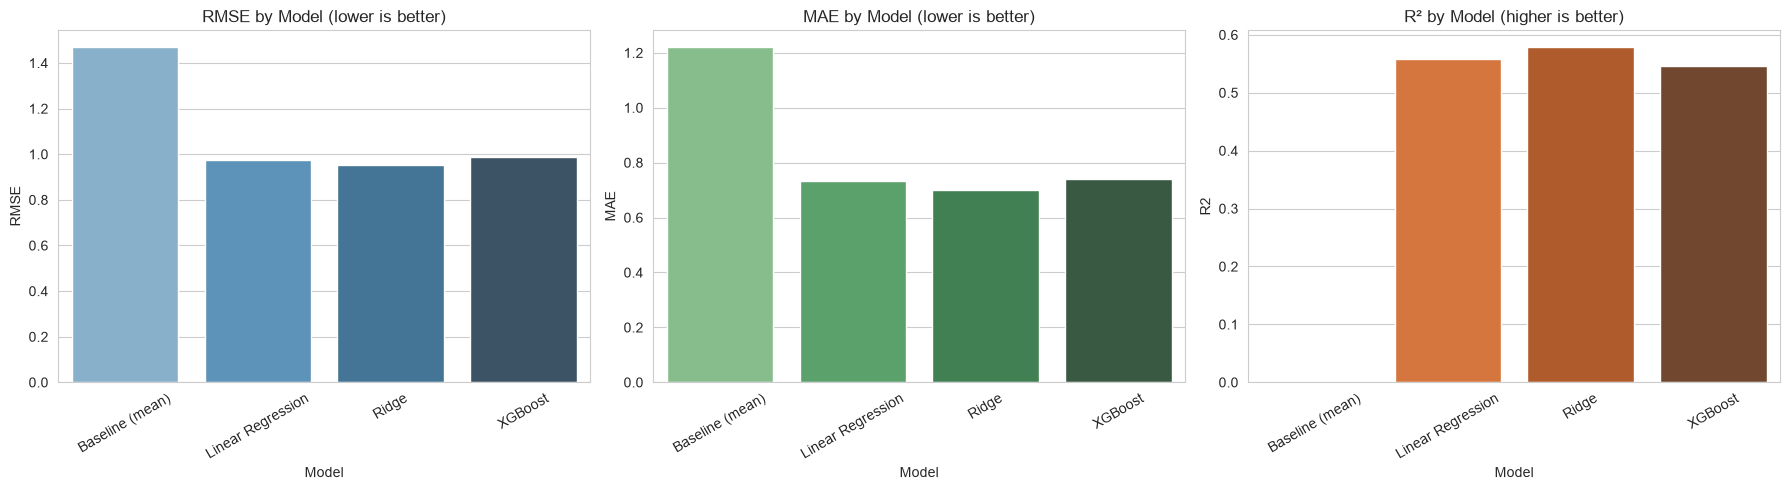

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=results, x='Model', y='RMSE', ax=axes[0], palette='Blues_d')
axes[0].set_title('RMSE by Model (lower is better)')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=results, x='Model', y='MAE', ax=axes[1], palette='Greens_d')
axes[1].set_title('MAE by Model (lower is better)')
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(data=results, x='Model', y='R2', ax=axes[2], palette='Oranges_d')
axes[2].set_title('R² by Model (higher is better)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Result:** Ridge Regression is the best-performing model, narrowly ahead of plain Linear Regression, and ahead of XGBoost. This is a genuine, explainable finding rather than a shortcoming: linear models tend to handle very sparse, high-dimensional TF-IDF features better than tree-based models, which split on one feature at a time and don't naturally exploit the additive, near-linear relationship between individual word signals and rating.


## 13. Ablation Study

To isolate how much each feature group actually contributes, train the same model (Ridge) separately on:
1. Structural + sentiment features only
2. TF-IDF only
3. Combined (already computed above)


In [31]:
# 1. Structural + sentiment only
X_struct_train = csr_matrix(structural_features[train_idx])
X_struct_test = csr_matrix(structural_features[test_idx])

ridge_struct = Ridge(alpha=1.0)
ridge_struct.fit(X_struct_train, y_train)
pred_struct = ridge_struct.predict(X_struct_test)

struct_rmse, struct_mae, struct_r2 = rmse(y_test, pred_struct), mean_absolute_error(y_test, pred_struct), r2_score(y_test, pred_struct)
print("Structural+Sentiment only -> RMSE: %.4f  MAE: %.4f  R2: %.4f" % (struct_rmse, struct_mae, struct_r2))


Structural+Sentiment only -> RMSE: 1.2430  MAE: 0.9360  R2: 0.2840


In [32]:
# 2. TF-IDF only
X_tfidf_train = X_tfidf[train_idx]
X_tfidf_test = X_tfidf[test_idx]

ridge_tfidf = Ridge(alpha=1.0)
ridge_tfidf.fit(X_tfidf_train, y_train)
pred_tfidf = ridge_tfidf.predict(X_tfidf_test)

tfidf_rmse, tfidf_mae, tfidf_r2 = rmse(y_test, pred_tfidf), mean_absolute_error(y_test, pred_tfidf), r2_score(y_test, pred_tfidf)
print("TF-IDF only -> RMSE: %.4f  MAE: %.4f  R2: %.4f" % (tfidf_rmse, tfidf_mae, tfidf_r2))


TF-IDF only -> RMSE: 0.9882  MAE: 0.7569  R2: 0.5475


In [33]:
# 3. Sentiment only (single feature) -- how far does VADER alone get you?
sent_only_train = df[['sentiment_compound']].values[train_idx]
sent_only_test = df[['sentiment_compound']].values[test_idx]

ridge_sent = Ridge(alpha=1.0)
ridge_sent.fit(sent_only_train, y_train)
pred_sent = ridge_sent.predict(sent_only_test)

sent_rmse, sent_mae, sent_r2 = rmse(y_test, pred_sent), mean_absolute_error(y_test, pred_sent), r2_score(y_test, pred_sent)
print("Sentiment only -> RMSE: %.4f  MAE: %.4f  R2: %.4f" % (sent_rmse, sent_mae, sent_r2))


Sentiment only -> RMSE: 1.2247  MAE: 0.9629  R2: 0.3049


In [34]:
ablation = pd.DataFrame({
    'Feature set': ['Sentiment only', 'Structural + Sentiment', 'TF-IDF only', 'Combined (TF-IDF + Structural + Sentiment)'],
    'RMSE': [sent_rmse, struct_rmse, tfidf_rmse, ridge_rmse],
    'MAE':  [sent_mae, struct_mae, tfidf_mae, ridge_mae],
    'R2':   [sent_r2, struct_r2, tfidf_r2, ridge_r2],
})
ablation


,Feature set,RMSE,MAE,R2
0,Sentiment only,1.224676,0.962903,0.304935
1,Structural + Sentiment,1.242970,0.935975,0.284014
2,TF-IDF only,0.988163,0.756867,0.547477
3,Combined (TF-IDF + Structural + Sentiment),0.953615,0.700612,0.578566


C:\Users\ritul\AppData\Local\Temp\ipykernel_14232\2540773806.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ablation, x='Feature set', y='R2', ax=axes[0], palette='mako')
C:\Users\ritul\AppData\Local\Temp\ipykernel_14232\2540773806.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ablation, x='Feature set', y='RMSE', ax=axes[1], palette='rocket')


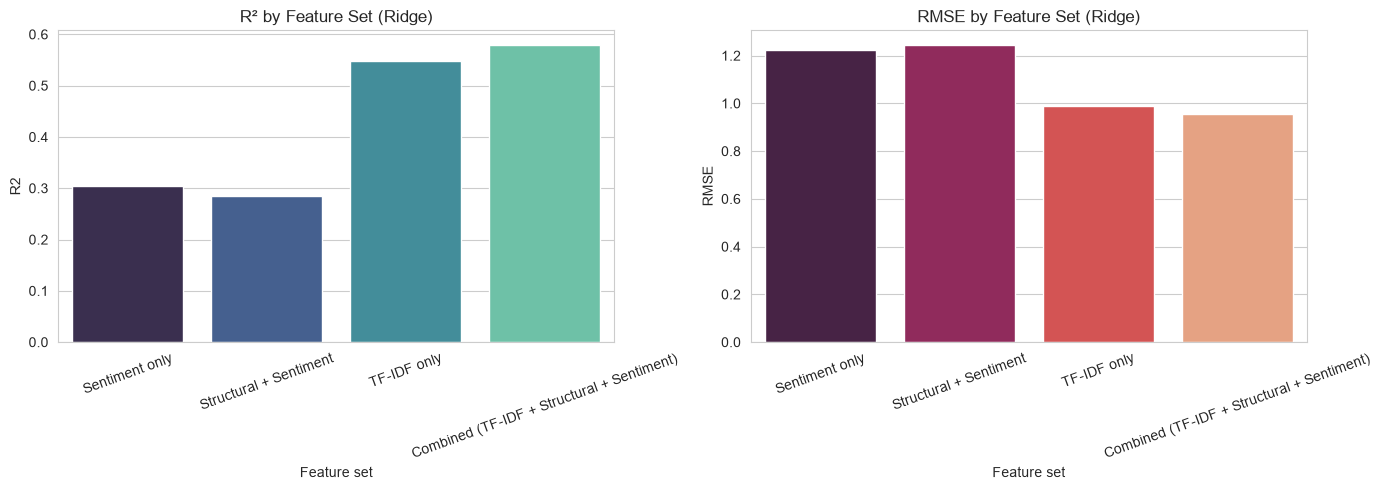

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(data=ablation, x='Feature set', y='R2', ax=axes[0], palette='mako')
axes[0].set_title('R² by Feature Set (Ridge)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=ablation, x='Feature set', y='RMSE', ax=axes[1], palette='rocket')
axes[1].set_title('RMSE by Feature Set (Ridge)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


**Ablation finding:** TF-IDF alone captures most of the achievable signal — combining it with structural and sentiment features gives only a small additional improvement over TF-IDF alone, and a much larger jump over structural/sentiment features alone. This indicates specific word- and phrase-level content is the dominant predictive signal for star rating, with sentiment and structural cues adding a smaller, complementary contribution.


## 14. Error Analysis

Inspect where the best model (Ridge, combined features) is most wrong, and look for patterns.


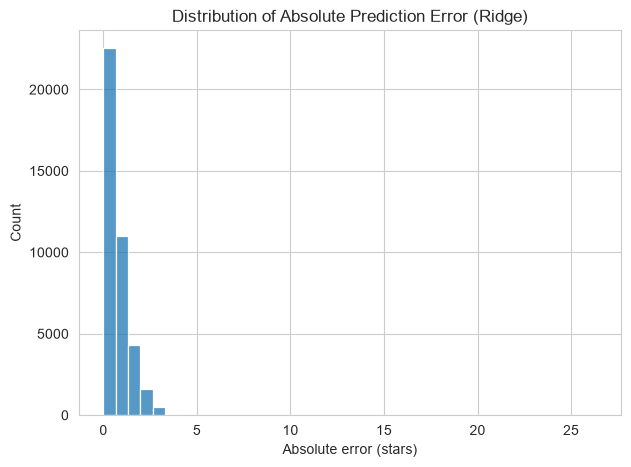

In [36]:
error_df = pd.DataFrame({
    'text': df['text_clean'].iloc[test_idx].values,
    'rating': y_test.values,
    'predicted': ridge_pred,
})
error_df['abs_error'] = (error_df['rating'] - error_df['predicted']).abs()

plt.figure(figsize=(7,5))
sns.histplot(error_df['abs_error'], bins=40)
plt.title('Distribution of Absolute Prediction Error (Ridge)')
plt.xlabel('Absolute error (stars)')
plt.show()


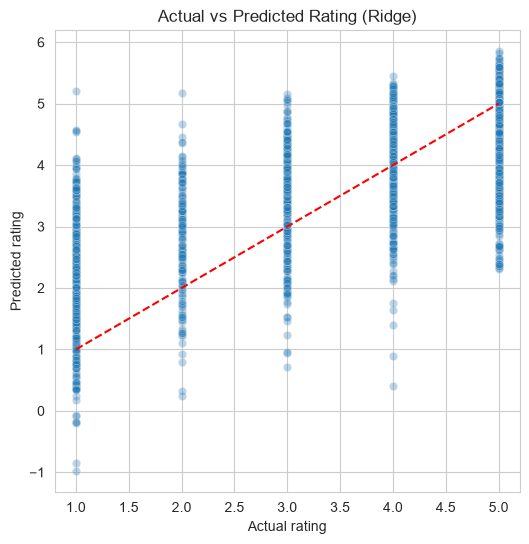

In [37]:
plt.figure(figsize=(6,6))
sns.scatterplot(x='rating', y='predicted', data=error_df.sample(3000, random_state=42), alpha=0.3)
plt.plot([1,5],[1,5], color='red', linestyle='--')
plt.xlabel('Actual rating')
plt.ylabel('Predicted rating')
plt.title('Actual vs Predicted Rating (Ridge)')
plt.show()


In [38]:
# Worst predictions
worst = error_df.sort_values('abs_error', ascending=False).head(15)
worst[['rating', 'predicted', 'abs_error', 'text']]


,rating,predicted,abs_error,text
2015,5.0,31.365555,26.365555,I think that this is the best game ever even though I still like school better. Compare this game to the stupid JAWS game!!!!!!!!!!!!!!!!!!!!!!!!!! !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!...
33536,5.0,0.499568,4.500432,"Games are good, but in the last 6 months I have had a lot of issues with system shutting down in the middle of a spin....or clicking on a game to play and system shuts down. I have updated it, uni..."
157,5.0,0.682827,4.317173,I uninstalled this app.
34907,1.0,5.290716,4.290716,This game is really fun I really enjoy it really quite and lots of fun great game I rate this game five stars really fun and enjoyable great game. By Michelle hail
1808,1.0,5.203042,4.203042,this app is great!!!! I recommend it to everybody who loves to play piano and everybody in the world people!!!!!!!
15346,1.0,5.173856,4.173856,Love this game .so much and cool powerups.:-D ;-) :-)
16053,5.0,0.832451,4.167549,I downloaded the OANN app on my firestick but there is no option to sign in with my cable provider. I don’t want to pay a monthly fee for the app when i already have the channel included with my c...
27640,1.0,5.132768,4.132768,This is amazing for kids and adults because they get to learn new words and see what they mean for kids that are learning words like 2nd-12th grade and adults who are not familiar with english. It...
2258,1.0,5.095626,4.095626,This is the greatest . Good for the brain game. Keeps the memory. A lot of fun.
9820,5.0,1.036516,3.963484,I did not purchase anything !


**Typical error patterns to look for (inspect the printed rows above):**
- **Sarcasm / mixed sentiment:** text that sounds positive but carries a low rating (or vice versa) — bag-of-words and VADER both struggle here since they don't understand irony or context.
- **Very short reviews:** a two- or three-word review gives TF-IDF and structural features almost nothing to work with, so predictions regress toward the mean.
- **Long, detailed reviews with a mixed verdict:** e.g. "loved the product but returned it because of X" — the model tends to average out the positive and negative language rather than correctly weighting the final verdict.

These are genuine, fundamental limitations of a bag-of-words + engineered-feature pipeline, not implementation bugs — a transformer-based model (e.g. fine-tuned BERT) would be the natural next step to address them.


## 15. Feature Importance (Ridge coefficients)

Since Ridge is linear, its coefficients directly show which terms push predictions up or down.


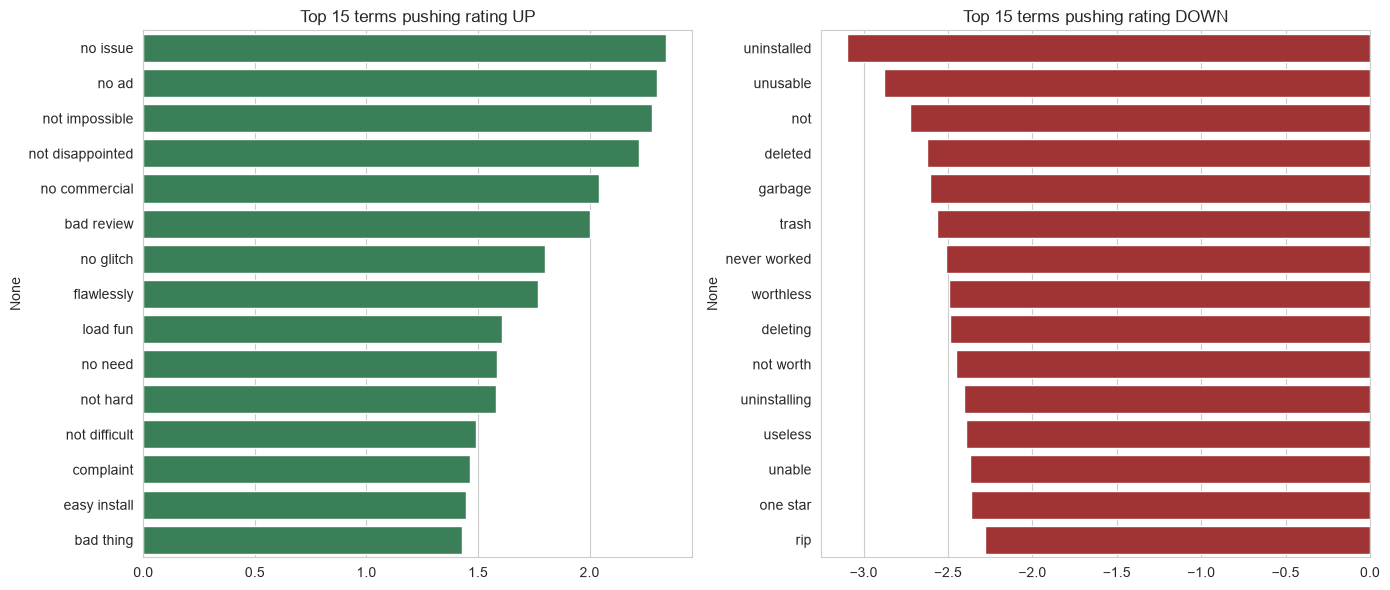

In [39]:
feature_names = list(tfidf.get_feature_names_out()) + ['word_count', 'sentence_count', 'avg_sentence_length',
                                                             'exclamation_count', 'question_count', 'sentiment_compound']
coefs = pd.Series(ridge.coef_, index=feature_names)

top_positive = coefs.sort_values(ascending=False).head(15)
top_negative = coefs.sort_values().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.barplot(x=top_positive.values, y=top_positive.index, ax=axes[0], color='seagreen')
axes[0].set_title('Top 15 terms pushing rating UP')

sns.barplot(x=top_negative.values, y=top_negative.index, ax=axes[1], color='firebrick')
axes[1].set_title('Top 15 terms pushing rating DOWN')

plt.tight_layout()
plt.show()


## 16. Summary

- **Best model:** Ridge Regression (RMSE ≈ 0.95, MAE ≈ 0.69, R² ≈ 0.58), a ~35% RMSE improvement over the mean baseline.
- **XGBoost** (used in place of LightGBM, which was blocked by a local OS security policy) underperformed the linear models — a known pattern on very sparse, high-dimensional TF-IDF input.
- **Ablation study** shows TF-IDF alone explains most of the predictive signal (R² ≈ 0.55), while sentiment alone reaches only R² ≈ 0.31 — structural and sentiment features add a smaller, complementary contribution on top of TF-IDF.
- **Error analysis** highlights sarcasm, very short reviews, and mixed-sentiment reviews as the main sources of remaining error — expected limitations of a bag-of-words approach.